In [1]:
from IPython.display import display, HTML
display(HTML("<h2>Agentic AI System</h2> \n " \
"<h3> Simple AI ChatBot"))

In [2]:
from typing import Annotated, List
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [3]:
class State(TypedDict):

    messages: Annotated[List, add_messages]




In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002790E8EE3C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002790E8EEE40>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# llm = init_chat_model("groq: llama3-8b-8192")
# llm

In [7]:
def ChatBot(state : State):

    return {
        "messages" : [llm.invoke(state["messages"])]
    }

In [8]:
graph_builder = StateGraph(State)

graph_builder.add_node("LLMChatNode", ChatBot)

graph_builder.add_edge(START, "LLMChatNode")
graph_builder.add_edge("LLMChatNode", END)

graph= graph_builder.compile()


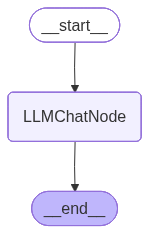

In [9]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [10]:
result = graph.invoke({"messages": "Hi, How Can I Assist You?"})

for msg in result["messages"]:
    msg.pretty_print()



================================ Human Message =================================

Hi, How Can I Assist You?
================================== Ai Message ==================================

I'm happy to assist you with any questions or topics you'd like to discuss. I'm a large language model, so I can:

1. **Answer questions**: I can provide information on a wide range of topics, from science and history to entertainment and culture.
2. **Generate text**: I can help with writing tasks, such as creating articles, stories, or even entire documents.
3. **Offer suggestions**: If you're stuck on a problem or need ideas, I can provide suggestions and recommendations.
4. **Practice conversations**: I can engage in natural-sounding conversations, making it feel like we're chatting with a friend.
5. **Translate text**: I can translate text from one language to another, helping you communicate with people from different countries.
6. **Summarize content**: If you have a long piece of text, I can

In [11]:
result["messages"]

[HumanMessage(content='Hi, How Can I Assist You?', additional_kwargs={}, response_metadata={}, id='9bfbb36b-fe8b-4637-a647-95f144306c7b'),
 AIMessage(content="I'm happy to assist you with any questions or topics you'd like to discuss. I'm a large language model, so I can:\n\n1. **Answer questions**: I can provide information on a wide range of topics, from science and history to entertainment and culture.\n2. **Generate text**: I can help with writing tasks, such as creating articles, stories, or even entire documents.\n3. **Offer suggestions**: If you're stuck on a problem or need ideas, I can provide suggestions and recommendations.\n4. **Practice conversations**: I can engage in natural-sounding conversations, making it feel like we're chatting with a friend.\n5. **Translate text**: I can translate text from one language to another, helping you communicate with people from different countries.\n6. **Summarize content**: If you have a long piece of text, I can summarize it for you, h

In [12]:
result["messages"][-1].content

"I'm happy to assist you with any questions or topics you'd like to discuss. I'm a large language model, so I can:\n\n1. **Answer questions**: I can provide information on a wide range of topics, from science and history to entertainment and culture.\n2. **Generate text**: I can help with writing tasks, such as creating articles, stories, or even entire documents.\n3. **Offer suggestions**: If you're stuck on a problem or need ideas, I can provide suggestions and recommendations.\n4. **Practice conversations**: I can engage in natural-sounding conversations, making it feel like we're chatting with a friend.\n5. **Translate text**: I can translate text from one language to another, helping you communicate with people from different countries.\n6. **Summarize content**: If you have a long piece of text, I can summarize it for you, highlighting the main points.\n7. **Learn a new skill**: I can help you learn a new language, a new subject, or even a new hobby.\n\nSo, what's on your mind? W

In [13]:
for event in graph.stream({"messages": "How Are You?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, so I don't have emotions or feelings like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How can I assist you today?


## ChatBot with Tavily

In [14]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results =2)

tool.invoke("What is LangGraph?")


{'query': 'What is LangGraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the 

In [28]:
def multiPly(a:int, b:int)->int:
    """
    Multipy a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: Output int
    
    """
    return a*b

In [29]:
tools = [tool, multiPly]

In [30]:
llm_with_tool = llm.bind_tools(tools)


In [31]:
llm_with_tool


_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002790E8EE3C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002790E8EEE40>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when 

## State Graph

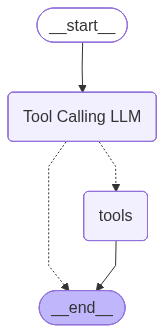

In [53]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode

builder = StateGraph(State)

def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tool.invoke(state["messages"])
        ]
    }

builder.add_node(
    "Tool Calling LLM",
    tool_calling_llm
)

builder.add_node(
    "tools",
    ToolNode(tools)
)

builder.add_edge(
    START,
    "Tool Calling LLM"
)

builder.add_conditional_edges(
    "Tool Calling LLM",
    tools_condition
)

builder.add_edge(
    "tools",
    END
)



graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [54]:
response = graph.invoke(
    {
        "messages": "What is FIFA News?"
    }
)

In [47]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is FIFA News?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (w3enm2n59)
 Call ID: w3enm2n59
  Args:
    query: FIFA News
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "FIFA News", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.mediapost.com/publications/article/415636/fifa-to-run-6-game-world-cup-crossover-on-roblox.html?edition=142846", "title": "FIFA To Run 6-Game World Cup Crossover On Roblox 06/09/2026 - MediaPost", "score": 0.43438992, "published_date": "Mon, 08 Jun 2026 21:13:10 GMT", "content": "by Colin Kirkland\n  ,\n  6 hours ago\n\nThe “Super Soccer” Roblox hub for FIFA is launching official events celebrating the 2026 World Cup and all 48 participating national teams, with pl

In [48]:
response = graph.invoke(
    {
        "messages": "What is 2 Multipy by 5?"
    }
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 Multipy by 5?
================================== Ai Message ==================================
Tool Calls:
  multiPly (0vpvwgtpx)
 Call ID: 0vpvwgtpx
  Args:
    a: 2
    b: 5
================================= Tool Message =================================
Name: multiPly

10


In [49]:
response = graph.invoke(
    {
        "messages": "What is 2 Multipy by 5 and then Muliply by 10?"
    }
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 Multipy by 5 and then Muliply by 10?
================================== Ai Message ==================================
Tool Calls:
  multiPly (zdvas9q48)
 Call ID: zdvas9q48
  Args:
    a: 2
    b: 5
  multiPly (dc599kjsg)
 Call ID: dc599kjsg
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: multiPly

10
================================= Tool Message =================================
Name: multiPly

100


In [50]:
response = graph.invoke(
    {
        "messages": "Give me Recent FIFA Portugal News and Then 8 Multiply by 9"
    }
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me Recent FIFA Portugal News and Then 8 Multiply by 9
================================== Ai Message ==================================
Tool Calls:
  tavily_search (85y8fc66b)
 Call ID: 85y8fc66b
  Args:
    query: Recent FIFA Portugal News
    topic: news
  multiPly (29g1ksmjt)
 Call ID: 29g1ksmjt
  Args:
    a: 8
    b: 9
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent FIFA Portugal News", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://apnews.com/article/portugal-ronaldo-world-cup-chile-9cb936a71e59ea84abd116510dc2c9a4", "title": "Portugal’s Leão sent off for punching in World Cup warmup win over Chile - AP News", "score": 0.5180835, "published_date": "Sat, 06 Jun 2026 20:13:33 GMT", "content": "Test Your News I.Q. 2026 Elections Election Results Election calendar White House Congress Sup

# ReAct Agent Architecture

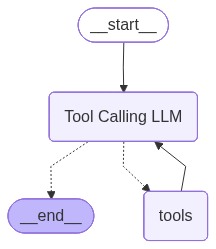

In [58]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import SystemMessage

system_prompt = """
You are a helpful AI assistant.

Always:
1. Use tools when needed.
2. After receiving tool results, summarize ALL tool outputs clearly.
3. Never ignore any tool result.
"""



def tool_calling_llm(state: State):

    messages = [
        SystemMessage(content=system_prompt)
    ] + state["messages"]

    return {
        "messages": [
            llm_with_tool.invoke(messages)
        ]
    }


builder = StateGraph(State)
builder.add_node(
    "Tool Calling LLM",
    tool_calling_llm
)

builder.add_node(
    "tools",
    ToolNode(tools)
)

builder.add_edge(
    START,
    "Tool Calling LLM"
)

builder.add_conditional_edges(
    "Tool Calling LLM",
    tools_condition
)

builder.add_edge(
    "tools",
    "Tool Calling LLM"
)



graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [59]:
response = graph.invoke(
    {
        "messages": "Give me Recent FIFA News and Then 8 Multiply by 9"
    }
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me Recent FIFA News and Then 8 Multiply by 9
================================== Ai Message ==================================
Tool Calls:
  tavily_search (23nvafap1)
 Call ID: 23nvafap1
  Args:
    include_images: True
    query: Recent FIFA News
    search_depth: advanced
    topic: news
  multiPly (qpf3stpjr)
 Call ID: qpf3stpjr
  Args:
    a: 8
    b: 9
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent FIFA News", "follow_up_questions": null, "answer": null, "images": ["https://images.wral.com/4e5334c9-b59d-526d-9d27-b2fc227b065c?w=1200&h=675&f=jpg", "https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=3916791063209118710", "https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=3916651120393469733", "https://vanderbiltreport.com/wp-content/uploads/2026/06/featured-image-1.png", "https://d3i6fh83elv3

In [60]:
final_response = response["messages"][-1].content

print(final_response)

The recent FIFA news includes an agreement between FIFA and the FIFPRO union on a cooperation deal covering transfers and player welfare, as well as updates on the World Cup, including team guides, latest news, and analysis. 

The result of multiplying 8 by 9 is 72.
